In [1]:
using Pkg; Pkg.add(["ITensors", "ITensorMPS", "Plots", "LsqFit", "Statistics", "LinearAlgebra", "ProgressMeter", "LaTeXStrings", "SavitzkyGolay"])
using ITensors, ITensorMPS, Plots, LsqFit, Statistics, LinearAlgebra, ProgressMeter, LaTeXStrings, SavitzkyGolay

include("../../data/params.jl")
include("../../data/helpers/saving.jl")
include("../schmidt_spectra/get_spectrum.jl")
include("../schmidt_spectra/deviation/deviation.jl")



    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
  No Changes to `~/dev/uni/msciproject/Project.toml`
  No Changes to `~/dev/uni/msciproject/Manifest.toml`


find_deviation_idx (generic function with 1 method)

In [2]:
function fetch_states(
    N::Int, σ::Float64, system_params::Dict{String, Any};
    max::Union{Nothing, Int}=nothing, type::Symbol=:latest
)::Tuple{Vector{MPS}, Vector{MPS}}
    CURRENT_DIR = @__DIR__
    FP = extract_filename_from_system_params(system_params)
    MPS_FP = joinpath(CURRENT_DIR, "../../data/storage/perturb_sigma_$(σ)_$(FP).hd5")
    matches_cln = find_runs_by_params(MPS_FP, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=type)
    matches_dis = find_runs_by_params(MPS_FP, Dict{String, Any}("N"=>N, "σ"=>σ); load_psi=true, instance_selection=type)

    cln_mpss = MPS[]
    dis_mpss = MPS[]

    for (cln, dis) in zip(matches_cln, matches_dis)
        if (cln.psi === nothing || dis.psi === nothing)
            continue
        end

        push!(cln_mpss, cln.psi)
        push!(dis_mpss, dis.psi)

        if max !== nothing && length(cln_mpss) >= max
            break
        end
    end

    return cln_mpss, dis_mpss
end

fetch_states (generic function with 1 method)

In [3]:
function get_squared_sorted_schmidt_spectrum_from_mps(psi::MPS)
    N = length(psi)

    # MIDDLE bond
    middle_bond = N ÷ 2

    orthogonalize!(psi, middle_bond)
    link_idx = linkind(psi, middle_bond)
    _, S, _ = svd(psi[middle_bond], (siteind(psi, middle_bond), link_idx))

    schmidt_dim = dim(S, 1)

    schmidt_vals = []
    for n in 1:schmidt_dim
        push!(schmidt_vals, S[n, n]) # steal diagonals
    end

    # sort desc and square
    return sort(schmidt_vals .^ 2, rev=true)
end

get_squared_sorted_schmidt_spectrum_from_mps (generic function with 1 method)

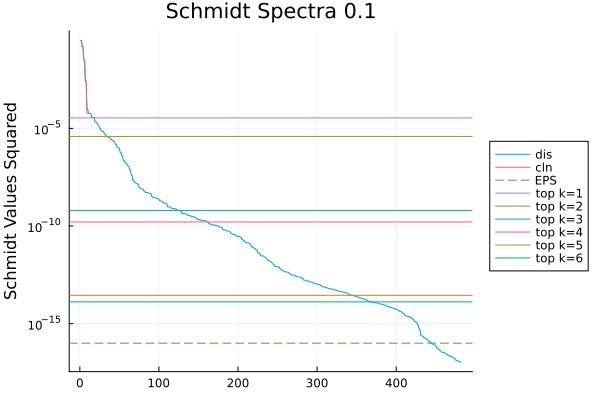

In [95]:
sysparams = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 25, "MAX_BOND_DIM" => 2000, "ACC" => 10^-16
)

N = 20
σ = 0.1

p = plot(title="Schmidt Spectra $σ", ylabel="Schmidt Values Squared", legend=:outerright,
    yscale=:log,
    # xscale=:log
)

cln, dis = fetch_states(N, σ, sysparams; type=:latest)
spectra = get_squared_sorted_schmidt_spectrum_from_mps(dis[1])
spectra_cln = get_squared_sorted_schmidt_spectrum_from_mps(cln[1])

println(spectra)

plot!(p, 1:length(spectra), spectra, label="dis")
plot!(p, 1:length(spectra_cln), spectra_cln, label="cln")

c = 0.33

D1(N) = N - 1
D2(N) = N * (N - 3) / 2
D3(N) = N * (N - 1) * (N - 5) / 6
D4(N) = N * (N - 1) * (N - 2) * (N - 7) / 24
D5(N) = N * (N - 1) * (N - 2) * (N - 3) * (N - 9) / 120
D6(N) = N * (N - 1) * (N - 2) * (N - 3) * (N - 4) * (N - 11) / 720

# 1st Order (sigma^2)
av_k1(c, σ, N) = (c * σ)^2 / D1(N)
av_k2(c, σ, N) = (c * σ)^2 / D2(N)

# 2nd Order (sigma^4)
av_k3(c, σ, N) = (c * σ)^4 / D3(N)
av_k4(c, σ, N) = (c * σ)^4 / D4(N)

# 3rd Order (sigma^6)
av_k5(c, σ, N) = (c * σ)^6 / D5(N)
av_k6(c, σ, N) = (c * σ)^6 / D6(N)


# hline!(p, [av_k1(c, σ, N)], label="k=1")
# hline!(p, [av_k2(c, σ, N)], label="k=2")
# hline!(p, [av_k3(c, σ, N)], label="k=3")
# hline!(p, [av_k4(c, σ, N)], label="k=4")
# hline!(p, [av_k5(c, σ, N)], label="k=5")
# hline!(p, [av_k6(c, σ, N)], label="k=6")

hline!(p, [1e-16], label="EPS", linestyle=:dash)

# 1st Order (sigma^2) Peaks
# 1st Order (sigma^2) - Divisor 3, suppressed by 1/N
top_k1(c, σ, N) = 4 * 3 * ((c * σ)^2 / (N * D1(N)))
top_k2(c, σ, N) = 4 * 3 * ((c * σ)^2 / (N * D2(N)))

# 2nd Order (sigma^4) - Divisor 5, suppressed by 1/N, 2! damping
top_k3(c, σ, N) = 4 * 5 * (((c * σ)^4 / 2.0) / (N * D3(N)))
top_k4(c, σ, N) = 4 * 5 * (((c * σ)^4 / 2.0) / (N * D4(N)))

# 3rd Order (sigma^6) - Divisor 7, suppressed by 1/N, 3! damping
top_k5(c, σ, N) = 4 * 7 * (((c * σ)^6 / 6.0) / (N * D5(N)))
top_k6(c, σ, N) = 4 * 7 * (((c * σ)^6 / 6.0) / (N * D6(N)))

hline!(p, [top_k1(c, σ, N)], label="top k=1")
hline!(p, [top_k2(c, σ, N)], label="top k=2")
hline!(p, [top_k3(c, σ, N)], label="top k=3")
hline!(p, [top_k4(c, σ, N)], label="top k=4")
hline!(p, [top_k5(c, σ, N)], label="top k=5")
hline!(p, [top_k6(c, σ, N)], label="top k=6")

# top_k12(c, σ, N) = 4 * 3 * ((c * σ)^2 / (D1(N) + D2(N)))
# top_k34(c, σ, N) = 4 * 5 * ((c * σ)^4 / (D3(N) + D4(N)))
# hline!(p, [top_k12(c, σ, N)], label="top k=12")
# hline!(p, [top_k34(c, σ, N)], label="top k=34")

# hline!(p, [σ^1 / D1(N)])
# hline!(p, [σ^2 / D2(N)])
# hline!(p, [σ^3 / D3(N)])
# hline!(p, [σ^4 / D4(N)])
# hline!(p, [σ^5 / D5(N)])
# hline!(p, [σ^6 / D6(N)])

# --- Add this before display(p) ---

# 1. Exact parameter predictions for k=1,2
# vol_12 = D1(N) + D2(N)
# capacity_12 = vol_12 / 3.0
# core_states = N / 2 + 1

# W_12 = (c * σ)^2
# mu_12 = W_12 / capacity_12
# L12 = 4.0 * mu_12 # The true MP peak

# # 2. Survival Fraction Function (Inverse CDF)
function mp_survival_fraction(u)
    if u >= 1.0 return 0.0 end
    if u <= 0.0 return 1.0 end
    return 1.0 - (2.0 / π) * (asin(sqrt(u)) + sqrt(u * (1.0 - u)))
end

# # 3. Generate the Parametric Curve
# # We sweep u from 1.0 (top of the band) down to 0.0 (bottom of the band)
# u_vals = range(1.0, 1e-15, length=200)

# x_theory = Float64[]
# y_theory = Float64[]

# for u in u_vals
#     # X is the starting core states + the fraction of capacity above u
#     push!(x_theory, core_states + capacity_12 * mp_survival_fraction(u))
#     # Y is the absolute Schmidt value squared
#     push!(y_theory, L12 * u)
# end

# # 4. Plot the overlay
# plot!(p, x_theory, y_theory, label="Theory k=1,2 Band", color=:red, linewidth=3)

# # === 2nd Shelf: k=3,4 ===
# vol_34 = D3(N) + D4(N)
# capacity_34 = vol_34 / 5.0
# L34 = 4.0 * ((c * σ)^4 / capacity_34)

# # It starts exactly where the survivors of the first band ended
# start_34 = core_states + capacity_12 * mp_survival_fraction(1e-16 / L12)

# x_theory_34 = Float64[]
# y_theory_34 = Float64[]

# for u in u_vals
#     push!(x_theory_34, start_34 + capacity_34 * mp_survival_fraction(u))
#     push!(y_theory_34, L34 * u)
# end

# plot!(p, x_theory_34, y_theory_34, label="Theory k=3,4 Band", color=:purple, linewidth=3)


# # === 3rd Shelf: k=5,6 ===
# vol_56 = D5(N) + D6(N)
# capacity_56 = vol_56 / 7.0
# L56 = 4.0 * ((c * σ)^6 / capacity_56)

# # It starts exactly where the survivors of the second band ended
# start_56 = start_34 + capacity_34 * mp_survival_fraction(1e-16 / L34)

# x_theory_56 = Float64[]
# y_theory_56 = Float64[]

# for u in u_vals
#     push!(x_theory_56, start_56 + capacity_56 * mp_survival_fraction(u))
#     push!(y_theory_56, L56 * u)
# end

# plot!(p, x_theory_56, y_theory_56, label="Theory k=5,6 Band", color=:orange, linewidth=3)

# function get_total_theoretical_index_phys(y, σ, N, c, spectra_cln)
#     # 1. Hard Physical Limit for a half-chain cut
#     # For N=18, this is 2^9 = 512
#     max_bipartite_rank = 2^(N ÷ 2)

#     # 2. Strict Weight Normalization
#     # Calculate raw weights and normalize them to sum to 1.0
#     w0 = 1.0
#     w12 = (c * σ)^2
#     w34 = (c * σ)^4 / 2.0
#     w56 = (c * σ)^6 / 6.0
#     total_w = w0 + w12 + w34 + w56

#     # Normalized weights
#     W12 = w12 / total_w
#     W34 = w34 / total_w
#     W56 = w56 / total_w

#     # 3. Summing the headcounts
#     x_total = count(val -> (val * (w0/total_w)) >= y, spectra_cln)

#     # Shelf 1: k=1,2
#     cap_12 = (D1(N) + D2(N)) / 3.0
#     L12 = 4.0 * (W12 / cap_12)
#     x_total += cap_12 * mp_survival_fraction(y / L12)

#     # Shelf 2: k=3,4
#     cap_34 = (D3(N) + D4(N)) / 5.0
#     L34 = 4.0 * (W34 / cap_34)
#     x_total += cap_34 * mp_survival_fraction(y / L34)

#     # 4. Final Physical Constraint: The Hard Wall
#     return min(x_total, max_bipartite_rank)
# end

# # Generate the Interleaved & Damped Curve
# y_sweep = 10 .^ range(log10(maximum(spectra)), log10(1e-22), length=500)
# x_theory_damped = Float64[]
# y_theory_damped = Float64[]

# for y in y_sweep
#     x_val = get_total_theoretical_index_phys(y, σ, N, c, spectra_cln)
#     if x_val > 0.5
#         push!(x_theory_damped, x_val)
#         push!(y_theory_damped, y)
#     end
# end

# plot!(p, x_theory_damped, y_theory_damped,
#       label="Theory (Damped & Sorted)",
#       color=:red, linewidth=3)

display(p)

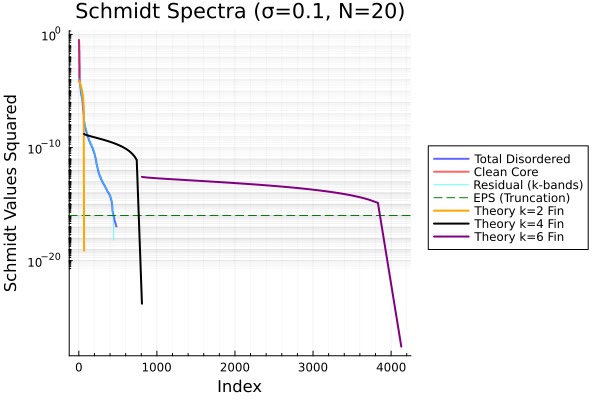

In [ ]:
using Plots

sysparams = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 25, "MAX_BOND_DIM" => 2000, "ACC" => 10^-16
)

N = 20
σ = 0.1
c = 0.33

p = plot(title="Schmidt Spectra (σ=$σ, N=$N)", ylabel="Schmidt Values Squared",
         xlabel="Index", legend=:outerright, yscale=:log, grid=:both, minorgrid=true)

cln, dis = fetch_states(N, σ, sysparams; type=:latest)
spectra = get_squared_sorted_schmidt_spectrum_from_mps(dis[1])
spectra_cln = get_squared_sorted_schmidt_spectrum_from_mps(cln[1])

function get_residual_state(ψ_σ::MPS, ψ_0::MPS; normalize::Bool = true)
    ξ = inner(ψ_σ, ψ_0)
    ψ_r = ψ_σ - ξ * ψ_0
    if normalize normalize!(ψ_r) end
    return ψ_r
end

res_spec = get_squared_sorted_schmidt_spectrum_from_mps(get_residual_state(dis[1], cln[1]; normalize=false))

plot!(p, 1:length(spectra), spectra, label="Total Disordered", color=:blue, lw=2, alpha=0.6)
plot!(p, 1:length(spectra_cln), spectra_cln, label="Clean Core", color=:red, lw=2, alpha=0.6)
plot!(p, 1:length(res_spec), res_spec, label="Residual (k-bands)", color=:cyan, alpha=0.6)

hline!(p, [1e-16], label="EPS (Truncation)", linestyle=:dash, color=:green)

# --- Combinatorial Dimensions (Even Only) ---
D2(N) = N * (N - 3) / 2
D4(N) = N * (N - 1) * (N - 2) * (N - 7) / 24
D6(N) = N * (N - 1) * (N - 2) * (N - 3) * (N - 4) * (N - 11) / 720

# --- Survival Fraction Function (Inverse CDF) ---
function mp_survival_fraction(u)
    if u >= 1.0 return 0.0 end
    if u <= 0.0 return 1.0 end
    return 1.0 - (2.0 / π) * (asin(sqrt(u)) + sqrt(u * (1.0 - u)))
end

# ==========================================
# PART 1: Stacked Shelves (Individual Bands)
# ==========================================
# u_vals = range(1.0, 1e-15, length=200)
# core_states = N / 2 + 1

# # === Shelf 1: k=2 ===
# capacity_2 = D2(N) / 3.0
# L2 = 4.0 * ((c * σ)^2 / (capacity_2 * 1))

# x_theory_2 = Float64[]
# y_theory_2 = Float64[]
# for u in u_vals
#     push!(x_theory_2, core_states + capacity_2 * mp_survival_fraction(u))
#     push!(y_theory_2, L2 * u)
# end
# plot!(p, x_theory_2, y_theory_2, label="Theory k=2 Fin", color=:orange, linewidth=2)

# # === Shelf 2: k=4 ===
# capacity_4 = D4(N) / 5.0
# L4 = 4.0 * (((c * σ)^4 / 2.0) / (capacity_4 * 2))
# start_4 = core_states + capacity_2 * mp_survival_fraction(1e-16 / L2)

# x_theory_4 = Float64[]
# y_theory_4 = Float64[]
# for u in u_vals
#     push!(x_theory_4, start_4 + capacity_4 * mp_survival_fraction(u))
#     push!(y_theory_4, L4 * u)
# end
# plot!(p, x_theory_4, y_theory_4, label="Theory k=4 Fin", color=:black, linewidth=2)

# # === Shelf 3: k=6 ===
# capacity_6 = D6(N) / 7.0
# L6 = 4.0 * (((c * σ)^6 / 6.0) / capacity_6)
# start_6 = start_4 + capacity_4 * mp_survival_fraction(1e-16 / L4)

# x_theory_6 = Float64[]
# y_theory_6 = Float64[]
# for u in u_vals
#     push!(x_theory_6, start_6 + capacity_6 * mp_survival_fraction(u))
#     push!(y_theory_6, L6 * u)
# end
# plot!(p, x_theory_6, y_theory_6, label="Theory k=6 Fin", color=:purple, linewidth=2)

# # ==========================================
# # PART 2: Interleaved & Sorted Theory Curve
# # ==========================================
# function get_total_theoretical_index_phys(y, σ, N, c, spectra_cln)
#     max_bipartite_rank = 2^(N ÷ 2)

#     # 1. Strict Weight Normalization
#     w0 = 1.0
#     w2 = (c * σ)^2
#     w4 = (c * σ)^4 / 2.0
#     w6 = (c * σ)^6 / 6.0
#     total_w = w0 + w2 + w4 + w6

#     W0 = w0 / total_w
#     W2 = w2 / total_w
#     W4 = w4 / total_w
#     W6 = w6 / total_w

#     # 2. Summing the headcounts at level y
#     x_total = count(val -> (val * W0) >= y, spectra_cln)

#     cap_2 = D2(N) / 3.0
#     L2_int = 4.0 * (W2 / cap_2)
#     x_total += cap_2 * mp_survival_fraction(y / L2_int)

#     cap_4 = D4(N) / 5.0
#     L4_int = 4.0 * (W4 / cap_4)
#     x_total += cap_4 * mp_survival_fraction(y / L4_int)

#     cap_6 = D6(N) / 7.0
#     L6_int = 4.0 * (W6 / cap_6)
#     x_total += cap_6 * mp_survival_fraction(y / L6_int)

#     return min(x_total, max_bipartite_rank)
# end

# # Generate the Smooth Integrated Curve
# y_sweep = 10 .^ range(log10(maximum(spectra)), log10(1e-22), length=500)
# x_theory_damped = Float64[]
# y_theory_damped = Float64[]

# for y in y_sweep
#     x_val = get_total_theoretical_index_phys(y, σ, N, c, spectra_cln)
#     if x_val > 0.5
#         push!(x_theory_damped, x_val)
#         push!(y_theory_damped, y)
#     end
# end

# plot!(p, x_theory_damped, y_theory_damped,
#       label="Theory (Interleaved & Sorted)",
#       color=:red, linewidth=3, linestyle=:dash)

display(p)

┌ Info: Saved animation to /Users/jamesneville-rolfe/dev/uni/msciproject/programs/random/schmidt_evolution.gif
└ @ Plots /Users/jamesneville-rolfe/.julia/packages/Plots/GIume/src/animation.jl:156


Plots.AnimatedGif("/Users/jamesneville-rolfe/dev/uni/msciproject/programs/random/schmidt_evolution.gif")
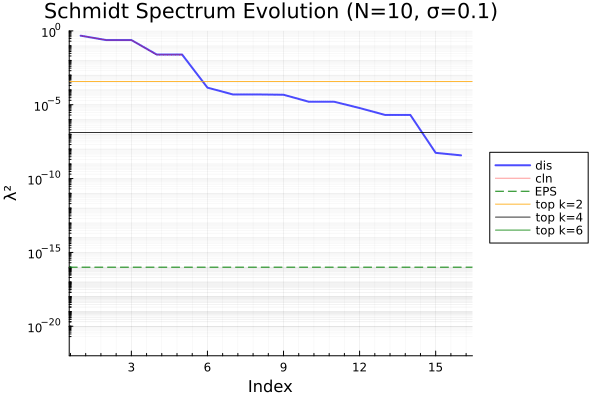

In [43]:
using Plots

# --- Constants and System Params ---
sysparams = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 25, "MAX_BOND_DIM" => 2000, "ACC" => 10^-16
)
σ = 0.1  # Note: At 1e-6, bands will hit EPS very quickly as N grows
c = 0.33
N_range = 10:2:80

D2(N) = N * (N - 3) / 2
D4(N) = N * (N - 1) * (N - 2) * (N - 7) / 24
D6(N) = N * (N - 1) * (N - 2) * (N - 3) * (N - 4) * (N - 11) / 720


top_k2(c, σ, N) = 4 * 3 * ((c * σ)^2 / D2(N))
top_k4(c, σ, N) = 4 * 5 * (((c * σ)^4 / 2.0) / D4(N))
top_k6(c, σ, N) = 4 * 7 * (((c * σ)^6 / 6.0) / D6(N))

# --- Animation Loop ---
anim = @animate for n in N_range
    cln, dis = fetch_states(n, σ, sysparams; type=:latest)

    if (!isempty(cln) && !isempty(dis))
        spectra = get_squared_sorted_schmidt_spectrum_from_mps(dis[1])
        spectra_cln = get_squared_sorted_schmidt_spectrum_from_mps(cln[1])

        # Setup plot with constant axes
        p = plot(title="Schmidt Spectrum Evolution (N=$n, σ=$σ)",
                ylabel="λ²", xlabel="Index",
                yscale=:log, ylims=(1e-22, 1),
                legend=:outerright, grid=:both, minorgrid=true)

        # Plot Simulation Data
        plot!(p, 1:length(spectra), spectra, label="dis", alpha=0.7, color=:blue, lw=2)
        plot!(p, 1:length(spectra_cln), spectra_cln, label="cln", alpha=0.4, color=:red)
        hline!(p, [1e-16], label="EPS", linestyle=:dash, color=:green)

        hline!(p, [top_k2(c, σ, n)], label="top k=2", color=:orange, alpha=0.8)
        hline!(p, [top_k4(c, σ, n)], label="top k=4", color=:black, alpha=0.8)
        hline!(p, [top_k6(c, σ, n)], label="top k=6", color=:green, alpha=0.8)
    end
end

# Save the animation
gif(anim, "schmidt_evolution.gif", fps=6)

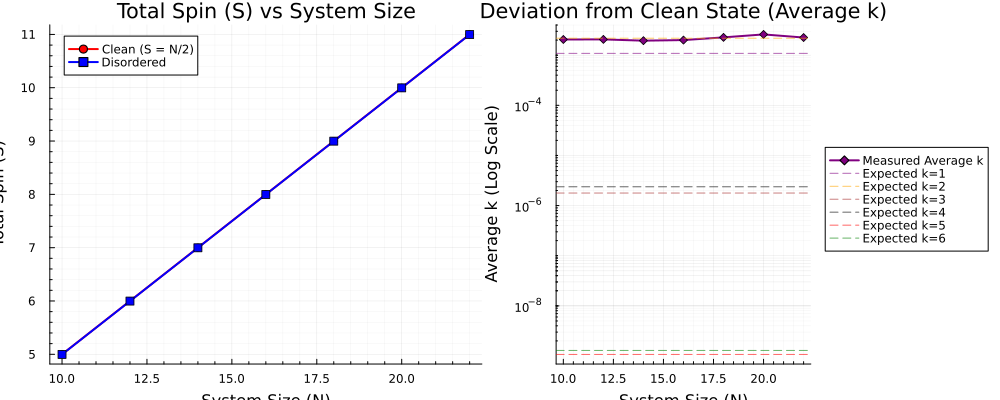

In [124]:
using Plots
using ITensors

# --- Constants and System Params ---
sysparams = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 25, "MAX_BOND_DIM" => 2000, "ACC" => 10^-16
)
σ = 0.1 # Using 0.1 so the band mixing is actually visible above truncation
N_range = 10:2:80

# --- Arrays to store the plotting data ---
N_vals = Int[]
S_cln_vals = Float64[]
S_dis_vals = Float64[]
k_eff_vals = Float64[]

# --- Helper Function for Total Spin ---
function compute_effective_S(psi)
    # Calculate two-site correlation matrices
    C_zz = correlation_matrix(psi, "Sz", "Sz")
    C_pm = correlation_matrix(psi, "S+", "S-")
    C_mp = correlation_matrix(psi, "S-", "S+")

    # Construct the S^2 expectation value matrix
    S2_mat = C_zz .+ 0.5 .* (C_pm .+ C_mp)

    # Sum all elements to get total <S^2>
    S2_val = real(sum(S2_mat))

    # Solve S(S+1) = <S^2> for S
    S_eff = (-1.0 + sqrt(1.0 + 4.0 * S2_val)) / 2.0
    return S_eff
end

# --- Data Gathering Loop ---
for n in N_range
    # Fetch states for current N
    cln, dis = fetch_states(n, σ, sysparams; type=:latest)

    if (!isempty(cln) && !isempty(dis))
        psi_cln = cln[1]
        psi_dis = dis[1]

        S_cln = compute_effective_S(psi_cln)
        S_dis = compute_effective_S(psi_dis)

        push!(N_vals, n)
        push!(S_cln_vals, S_cln)
        push!(S_dis_vals, S_dis)

        # Effective k is how far we've fallen from the N/2 ceiling
        push!(k_eff_vals, (n / 2.0) - S_dis)
    end
end

# --- Create the Static Plots ---
# Plot 1: Total Spin S vs N (Keeping this linear to show the macroscopic state)
p1 = plot(title="Total Spin (S) vs System Size",
          xlabel="System Size (N)", ylabel="Total Spin (S)",
          legend=:topleft, grid=:both, minorgrid=true)

plot!(p1, N_vals, S_cln_vals, label="Clean (S = N/2)", marker=:circle, lw=2, color=:red)
plot!(p1, N_vals, S_dis_vals, label="Disordered", marker=:square, lw=2, color=:blue)

p2 = plot(title="Deviation from Clean State (Average k)",
          xlabel="System Size (N)", ylabel="Average k (Log Scale)",
          yscale=:log10,
          legend=:outerright, grid=:both, minorgrid=true)

plot!(p2, N_vals, k_eff_vals .+ 1e-16, label="Measured Average k", marker=:diamond, lw=2, color=:purple)

w12 = (c * σ)^2
w34 = ((c * σ)^4) / 2.0
w56 = ((c * σ)^6) / 6.0

hline!(p2, [1.0 * w12], label="Expected k=1", linestyle=:dash, color=:purple, alpha=0.6)
hline!(p2, [2.0 * w12], label="Expected k=2", linestyle=:dash, color=:orange, alpha=0.6)

hline!(p2, [3.0 * w34], label="Expected k=3", linestyle=:dash, color=:brown, alpha=0.6)
hline!(p2, [4.0 * w34], label="Expected k=4", linestyle=:dash, color=:black, alpha=0.6)

hline!(p2, [5.0 * w56], label="Expected k=5", linestyle=:dash, color=:red, alpha=0.6)
hline!(p2, [6.0 * w56], label="Expected k=6", linestyle=:dash, color=:green, alpha=0.6)

display(plot(p1, p2, layout=(1, 2), size=(1000, 400)))

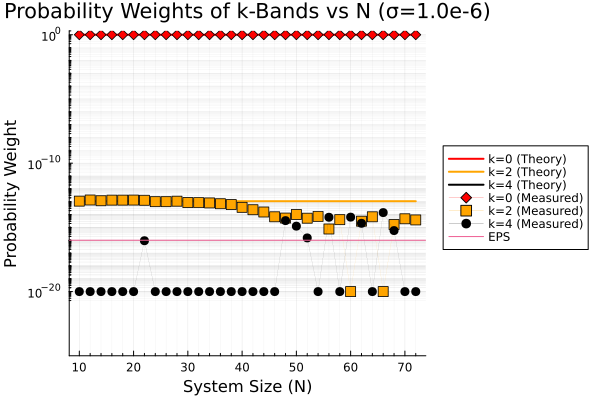

In [29]:
using Plots
using ITensors

sysparams = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 25, "MAX_BOND_DIM" => 2000, "ACC" => 10^-16
)
σ = 1e-6
c = 0.33
N_range = 10:2:80

# Theoretical Weights
W2_th(N) = (c * σ)^2
W4_th(N) = ((c * σ)^4) / 2.0
# The clean core retains whatever weight hasn't leaked into the higher bands
W0_th(N) = 1.0 - W2_th(N) - W4_th(N)

N_vals = Int[]
W0_meas = Float64[]
W2_meas = Float64[]
W4_meas = Float64[]

for n in N_range
    cln, dis = fetch_states(n, σ, sysparams; type=:latest)

    if !isempty(cln) && !isempty(dis)
        psi_cln = cln[1]
        psi_dis = dis[1]

        sites = siteinds(psi_cln)

        # Build the S^2 MPO
        os = OpSum()
        for i=1:n, j=1:n
            if i != j
                os += 0.5, "S+", i, "S-", j
                os += 0.5, "S-", i, "S+", j
                os += "Sz", i, "Sz", j
            else
                os += 0.75, "Id", i
            end
        end
        S2_mpo = MPO(os, sites)

        # Exact clean overlap (k=0)
        w0 = abs(inner(psi_cln, psi_dis))^2

        # First moment of Total Spin
        M1 = real(inner(psi_dis', S2_mpo, psi_dis))

        S0 = n / 2.0
        S2 = S0 - 2.0
        S4 = S0 - 4.0

        lam0 = S0 * (S0 + 1.0)
        lam2 = S2 * (S2 + 1.0)
        lam4 = S4 * (S4 + 1.0)

        rem_weight = 1.0 - w0
        rem_M1 = M1 - (lam0 * w0)

        # Solve the 2x2 system for w2 and w4
        raw_w4 = (rem_M1 - lam2 * rem_weight) / (lam4 - lam2)
        w4 = max(raw_w4, 1e-20)

        raw_w2 = rem_weight - w4
        w2 = max(raw_w2, 1e-20)

        push!(N_vals, n)
        push!(W0_meas, w0)
        push!(W2_meas, w2)
        push!(W4_meas, w4)
    end
end

p = plot(title="Probability Weights of k-Bands vs N (σ=$σ)",
         xlabel="System Size (N)", ylabel="Probability Weight",
         yscale=:log10, legend=:outerright, grid=:both, minorgrid=true)

# Plot Theory
plot!(p, N_vals, fill(W0_th(N_vals[1]), length(N_vals)), label="k=0 (Theory)", color=:red, lw=2)
plot!(p, N_vals, fill(W2_th(N_vals[1]), length(N_vals)), label="k=2 (Theory)", color=:orange, lw=2)
plot!(p, N_vals, fill(W4_th(N_vals[1]), length(N_vals)), label="k=4 (Theory)", color=:black, lw=2)

# Plot Measured
plot!(p, N_vals, W0_meas, label="k=0 (Measured)", marker=:diamond, color=:red, markersize=5, lw=0)
plot!(p, N_vals, W2_meas, label="k=2 (Measured)", marker=:square, color=:orange, markersize=5, lw=0)
plot!(p, N_vals, W4_meas, label="k=4 (Measured)", marker=:circle, color=:black, markersize=5, lw=0)

hline!(p, [1e-16], label="EPS")

# Optional: Set y-limits to ensure everything is visible and looks clean
ylims!(p, 1e-25, 2.0)

display(p)

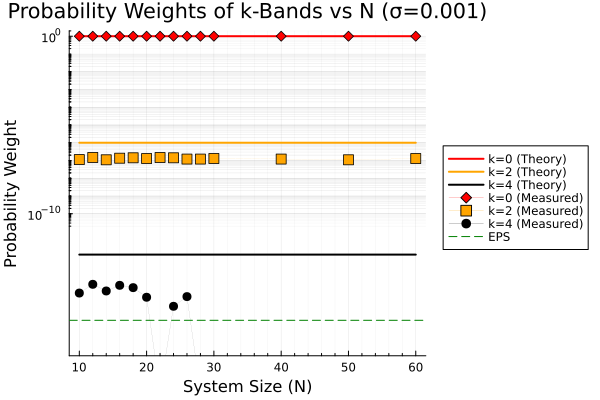

In [ ]:
using Plots
using ITensors

sysparams = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 25, "MAX_BOND_DIM" => 2000, "ACC" => 10^-16
)
σ = 0.001
c = 0.33
N_range = 10:2:80

# Theoretical Weights
W2_th(N) = (c * σ)^2
W4_th(N) = ((c * σ)^4) / 2.0
# The clean core retains whatever weight hasn't leaked into the higher bands
W0_th(N) = 1.0 - W2_th(N) - W4_th(N)

N_vals = Int[]
W0_meas = Float64[]
W2_meas = Float64[]
W4_meas = Float64[]

for n in N_range
    cln, dis = fetch_states(n, σ, sysparams; type=:latest)

    if !isempty(cln) && !isempty(dis)
        psi_cln = cln[1]
        psi_dis = dis[1]

        sites = siteinds(psi_cln)

        # Build the S^2 MPO
        os = OpSum()
        for i=1:n, j=1:n
            if i != j
                os += 0.5, "S+", i, "S-", j
                os += 0.5, "S-", i, "S+", j
                os += "Sz", i, "Sz", j
            else
                os += 0.75, "Id", i
            end
        end
        S2_mpo = MPO(os, sites)

        # Exact clean overlap (k=0)
        w0 = abs(inner(psi_cln, psi_dis))^2

        # First moment of Total Spin
        M1 = real(inner(psi_dis', S2_mpo, psi_dis))

        S0 = n / 2.0
        S2 = S0 - 2.0
        S4 = S0 - 4.0

        lam0 = S0 * (S0 + 1.0)
        lam2 = S2 * (S2 + 1.0)
        lam4 = S4 * (S4 + 1.0)

        rem_weight = 1.0 - w0
        rem_M1 = M1 - (lam0 * w0)

        # --- SIGNAL TO NOISE GATE ---
        # 1e-13 is a safe threshold for accumulated MPO contraction noise
        noise_floor = 1e-20

        if rem_weight < noise_floor
            # The state is essentially clean; don't let the solver hallucinate k=4 states
            w2 = 1e-20
            w4 = 1e-20
        else
            # Solve the 2x2 system for w2 and w4
            raw_w4 = (rem_M1 - lam2 * rem_weight) / (lam4 - lam2)
            w4 = max(raw_w4, 1e-20)

            raw_w2 = rem_weight - w4
            w2 = max(raw_w2, 1e-20)
        end
        # ----------------------------

        push!(N_vals, n)
        push!(W0_meas, w0)
        push!(W2_meas, w2)
        push!(W4_meas, w4)
    end
end

p = plot(title="Probability Weights of k-Bands vs N (σ=$σ)",
         xlabel="System Size (N)", ylabel="Probability Weight",
         yscale=:log10, legend=:outerright, grid=:both, minorgrid=true)

# Plot Theory
plot!(p, N_vals, fill(W0_th(N_vals[1]), length(N_vals)), label="k=0 (Theory)", color=:red, lw=2)
plot!(p, N_vals, fill(W2_th(N_vals[1]), length(N_vals)), label="k=2 (Theory)", color=:orange, lw=2)
plot!(p, N_vals, fill(W4_th(N_vals[1]), length(N_vals)), label="k=4 (Theory)", color=:black, lw=2)

# Plot Measured
plot!(p, N_vals, W0_meas, label="k=0 (Measured)", marker=:diamond, color=:red, markersize=5, lw=0)
plot!(p, N_vals, W2_meas, label="k=2 (Measured)", marker=:square, color=:orange, markersize=5, lw=0)
plot!(p, N_vals, W4_meas, label="k=4 (Measured)", marker=:circle, color=:black, markersize=5, lw=0)

hline!(p, [1e-16], label="EPS", linestyle=:dash, color=:green)

# Optional: Set y-limits to ensure everything is visible and looks clean
ylims!(p, 1e-18, 2.0)

display(p)

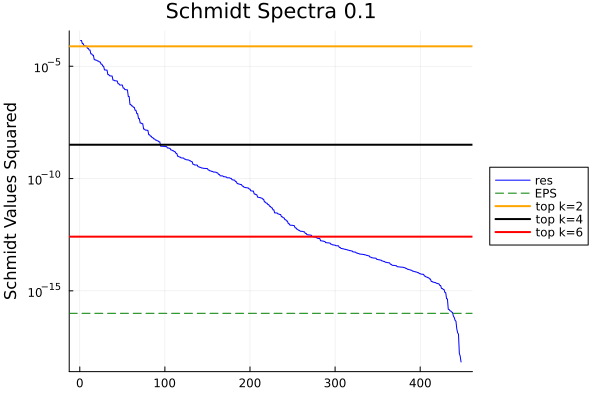

In [9]:
sysparams = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 25, "MAX_BOND_DIM" => 2000, "ACC" => 10^-16
)

N = 20
σ = 0.1

p = plot(title="Schmidt Spectra $σ", ylabel="Schmidt Values Squared", legend=:outerright,
    yscale=:log,
    # xscale=:log
)

cln, dis = fetch_states(N, σ, sysparams; type=:latest)
spectra = get_squared_sorted_schmidt_spectrum_from_mps(dis[1])
spectra_cln = get_squared_sorted_schmidt_spectrum_from_mps(cln[1])

function get_residual_state(ψ_σ::MPS, ψ_0::MPS; normalize::Bool = true)
    ξ = inner(ψ_σ, ψ_0)
    ψ_r = ψ_σ - ξ * ψ_0
    if normalize normalize!(ψ_r) end
    return ψ_r
end

res_spec = get_squared_sorted_schmidt_spectrum_from_mps(get_residual_state(dis[1], cln[1]; normalize=false))

plot!(p, 1:length(res_spec), res_spec, label="res", color=:blue)

c = 0.33

D2(N) = N * (N - 3) / 2
D4(N) = N * (N - 1) * (N - 2) * (N - 7) / 24
D6(N) = N * (N - 1) * (N - 2) * (N - 3) * (N - 4) * (N - 11) / 720

hline!(p, [1e-16], label="EPS", linestyle=:dash, color=:green)

top_k2(c, σ, N) = 4 * 3 * ((c * σ)^2 / D2(N))
top_k4(c, σ, N) = 4 * 5 * (((c * σ)^4 / 2.0) / D4(N))
top_k6(c, σ, N) = 4 * 7 * (((c * σ)^6 / 6.0) / D6(N))

hline!(p, [top_k2(c, σ, N)], label="top k=2", color=:orange, lw=2)
hline!(p, [top_k4(c, σ, N)], label="top k=4", color=:black, lw=2)
hline!(p, [top_k6(c, σ, N)], label="top k=6", color=:red, lw=2)

display(p)

In [85]:
function mp_sorted(x_vals, l1, l2, s)
    result = Float64[]
    for x in x_vals
        # push zero when x is outside the interval [l1, l2],
        # otherwise push the semicircle value
        if x < l1 || x > l2
            push!(result, 0.0)
        else
            push!(result, sqrt( (l1^2 - x^2) * (x^2 - l2^2) / (2π * s^2 * x^2) ))
        end
    end

    return sort(result; rev=true)
end

p_test = plot(title="Schmidt Spectra $σ", ylabel="Schmidt Values Squared", legend=:outerright,
    yscale=:log)
plot!(p_test, 1:1:100, mp_sorted(1:1:100, 0.0, 100.0, 1))
plot!(p_test, 1:1:100, mp_sorted(1:1:500, 50.0, 150.0, 0.5))
plot!(p_test, 1:1:100, sort(vcat(mp_sorted(1:1:100, 0.0, 100.0, 1), mp_sorted(1:1:500, 50.0, 150.0, 0.5)); rev=true))

display(p_test)


σ=0.001 100%|████████████████████████████████████████████| Time: 0:00:03
σ=0.0001 100%|███████████████████████████████████████████| Time: 0:00:03
σ=0.01 100%|█████████████████████████████████████████████| Time: 0:00:00


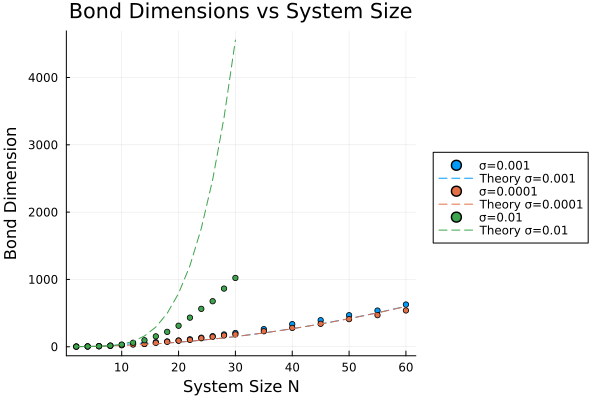

In [17]:

using SpecialFunctions

function mp_survival_fraction(u)
    if u >= 1.0
        return 0.0
    elseif u <= 0.0
        return 1.0
    end
    return 1.0 - (2.0 / π) * (asin(sqrt(u)) + sqrt(u * (1.0 - u)))
end

function predict_chi_analytic(valid_Ns, σ, ε; c=0.33)
    predicted = Float64[]

    D2(N) = N * (N - 3) / 2
    D4(N) = N * (N - 1) * (N - 2) * (N - 7) / 24
    D6(N) = N * (N - 1) * (N - 2) * (N - 3) * (N - 4) * (N - 11) / 720

    for N in valid_Ns
        chi_total = N / 2 + 1

        vol_2 = max(0.0, D2(N))
        if vol_2 > 0
            capacity_2 = vol_2 / 3.0
            L2 = 4.0 * ((c * σ)^2 / capacity_2)
            u2 = ε / L2
            chi_total += mp_survival_fraction(u2) * capacity_2
        end

        vol_4 = max(0.0, D4(N))
        if vol_4 > 0
            capacity_4 = vol_4 / 5.0
            L4 = 4.0 * (((c * σ)^4 / 2.0) / capacity_4)
            u4 = ε / L4
            chi_total += mp_survival_fraction(u4) * capacity_4
        end

        vol_6 = max(0.0, D6(N))
        if vol_6 > 0
            capacity_6 = vol_6 / 7.0
            L6 = 4.0 * (((c * σ)^6 / 6.0) / capacity_6)
            u6 = ε / L6
            chi_total += mp_survival_fraction(u6) * capacity_6
        end

        push!(predicted, chi_total)
    end

    return predicted
end


system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 25,
                    "MAX_BOND_DIM" => 2000,
                    "ACC" => 1e-16
                )

Ns = 2:1:80
σs = [
    # 5e-7,
    # 9e-7,
    # 0.0001,
    0.001,
    0.0001,
    0.01,
    # 0.1,
    ]

p3 = plot(
             title="Bond Dimensions vs System Size",
             xlabel="System Size N", ylabel="Bond Dimension",

             legend=:outerright, grid=true)

for (idx, σ) in enumerate(σs)
    bond_dims = Float64[]
    errs = Float64[]
    valid_Ns = Float64[]

    prog = Progress(length(Ns); desc="σ=$σ")

    for N in Ns
        ψ0s, ψσs = fetch_states(N, σ, system_params; type=:latest)
        if !isempty(ψ0s) && !isempty(ψσs)
            bond_ds = [maxlinkdim(ps) for (ps, pc) in zip(ψσs, ψ0s)]
            push!(bond_dims, mean(bond_ds))
            push!(errs, std(bond_ds) / sqrt(length(bond_ds)))
            push!(valid_Ns, N)
        end
        next!(prog)
    end

    function residual_envelope(N_array, k_max)
        return [binomial(BigInt(n), k_max) - 1 for n in N_array]
    end

    # Plot this sigma's data
    if !isempty(valid_Ns)
        scatter!(p3, valid_Ns, bond_dims, yerr=errs,
              label="σ=$σ",
              color=idx,
              marker=:circle,
              markersize=3,
              linewidth=2)
    end

  if !isempty(valid_Ns)
    # Plot predicted curve
    y_pred = predict_chi_analytic(valid_Ns, σ, 1e-16; c=0.33)
    plot!(p3, valid_Ns, y_pred, label="Theory σ=$σ", linestyle=:dash, color=idx)
end


end

display(p3)

In [11]:
using SpecialFunctions

function mp_survival_fraction(u)
    if u >= 1.0
        return 0.0
    elseif u <= 0.0
        return 1.0
    end
    return 1.0 - (2.0 / π) * (asin(sqrt(u)) + sqrt(u * (1.0 - u)))
end

function participation_ratio(σ, σ_c)
    return 1.0 - exp(-σ / σ_c)
end

function predict_chi_pr(valid_Ns, σ, ε; c=0.33, σ_c=1e-4)
    predicted = Float64[]

    D1(N) = N - 1
    D2(N) = N * (N - 3) / 2
    D3(N) = N * (N - 1) * (N - 5) / 6
    D4(N) = N * (N - 1) * (N - 2) * (N - 7) / 24

    for N in valid_Ns
        chi_total = N / 2 + 1

        pr = participation_ratio(σ, σ_c)

        vol_12 = max(0.0, D1(N)) + max(0.0, D2(N))
        if vol_12 > 0
            cap_12 = vol_12 / 3.0
            eff_cap_12 = max(1.0, cap_12 * pr)
            L12 = 4.0 * ((c * σ)^2 / eff_cap_12)
            chi_total += mp_survival_fraction(ε / L12) * eff_cap_12
        end

        vol_34 = max(0.0, D3(N)) + max(0.0, D4(N))
        if vol_34 > 0
            cap_34 = vol_34 / 5.0
            eff_cap_34 = max(1.0, cap_34 * pr)
            L34 = 4.0 * ((c * σ)^4 / eff_cap_34)
            chi_total += mp_survival_fraction(ε / L34) * eff_cap_34
        end

        push!(predicted, chi_total)
    end

    return predicted
end

system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 25,
                    "MAX_BOND_DIM" => 2000,
                    "ACC" => 1e-16
                )

Ns = 2:1:80
σs = [
    5e-7,
    9e-7,
    # 0.0001,
    # 0.001,
    # 0.0001
    # 0.01,
    # 0.1,
    ]

p3 = plot(
             title="Bond Dimensions vs System Size",
             xlabel="System Size N", ylabel="Bond Dimension",

             legend=:outerright, grid=true)

for (idx, σ) in enumerate(σs)
    bond_dims = Float64[]
    errs = Float64[]
    valid_Ns = Float64[]

    prog = Progress(length(Ns); desc="σ=$σ")

    for N in Ns
        ψ0s, ψσs = fetch_states(N, σ, system_params; type=:latest)
        if !isempty(ψ0s) && !isempty(ψσs)
            bond_ds = [maxlinkdim(ps) for (ps, pc) in zip(ψσs, ψ0s)]
            push!(bond_dims, mean(bond_ds))
            push!(errs, std(bond_ds) / sqrt(length(bond_ds)))
            push!(valid_Ns, N)
        end
        next!(prog)
    end

    function residual_envelope(N_array, k_max)
        return [binomial(BigInt(n), k_max) - 1 for n in N_array]
    end

    # Plot this sigma's data
    if !isempty(valid_Ns)
        scatter!(p3, valid_Ns, bond_dims, yerr=errs,
              label="σ=$σ",
              color=idx,
              marker=:circle,
              markersize=3,
              linewidth=2)
    end

  if !isempty(valid_Ns)
    # Plot predicted curve
    y_pred = predict_chi_pr(valid_Ns, σ, 1e-16; c=0.33, σ_c=1e-9)
    plot!(p3, valid_Ns, y_pred, label="Theory σ=$σ", linestyle=:dash, color=idx)
end


end

display(p3)

σ=5.0e-7  48%|████████████████████▋                      |  ETA: 0:00:04┌ Warning: Direct read into MPS failed for run 40 instance 14; attempting raw read for diagnostics.
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/data/helpers/saving.jl:559
┌ Info: Raw read type: Dict{String, Any}
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/data/helpers/saving.jl:566
┌ Info: Raw read keys: ["MPS[20]", "MPS[32]", "MPS[22]", "MPS[3]", "MPS[6]", "MPS[24]", "length", "MPS[36]", "MPS[39]", "MPS[18]", "MPS[15]", "MPS[1]", "MPS[26]", "MPS[17]", "MPS[12]", "MPS[28]", "MPS[27]", "MPS[21]", "MPS[7]", "MPS[5]", "MPS[38]", "MPS[29]", "MPS[10]", "MPS[16]", "MPS[19]", "MPS[35]", "MPS[8]", "MPS[23]", "MPS[40]", "MPS[13]", "MPS[9]", "MPS[30]", "MPS[25]", "MPS[33]", "MPS[4]", "MPS[11]", "MPS[14]", "MPS[37]", "llim", "MPS[2]", "MPS[31]", "rlim", "MPS[34]"]
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/data/helpers/saving.jl:568


InterruptException: InterruptException: